<a href="https://colab.research.google.com/github/Roaa27/HAR_CNN_LSTM/blob/main/HAR_CNN_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python
!apt-get install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-03-28 14:23:45--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar           15%[==>                 ]   1.01G  12.9MB/s    in 83s     

2026-03-28 14:25:09 (12.5 MB/s) - Connection closed at byte 1086258723. Retrying.

--2026-03-28 14:25:10--  (try: 2)  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 206 Partial Content
Length: 6932971618 (6.5G), 5846712895 (5.4G) remaining [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar           31%[+++==>            

In [ ]:
!ls

sample_data  UCF101.rar


In [ ]:
!unrar x UCF101.rar

Streaming output truncated to the last 5000 lines.
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGu

In [ ]:
!ls /content/UCF-101

ApplyEyeMakeup	   Drumming	       MilitaryParade	   Shotput
ApplyLipstick	   Fencing	       Mixing		   SkateBoarding
Archery		   FieldHockeyPenalty  MoppingFloor	   Skiing
BabyCrawling	   FloorGymnastics     Nunchucks	   Skijet
BalanceBeam	   FrisbeeCatch        ParallelBars	   SkyDiving
BandMarching	   FrontCrawl	       PizzaTossing	   SoccerJuggling
BaseballPitch	   GolfSwing	       PlayingCello	   SoccerPenalty
Basketball	   Haircut	       PlayingDaf	   StillRings
BasketballDunk	   Hammering	       PlayingDhol	   SumoWrestling
BenchPress	   HammerThrow	       PlayingFlute	   Surfing
Biking		   HandstandPushups    PlayingGuitar	   Swing
Billiards	   HandstandWalking    PlayingPiano	   TableTennisShot
BlowDryHair	   HeadMassage	       PlayingSitar	   TaiChi
BlowingCandles	   HighJump	       PlayingTabla	   TennisSwing
BodyWeightSquats   HorseRace	       PlayingViolin	   ThrowDiscus
Bowling		   HorseRiding	       PoleVault	   TrampolineJumping
BoxingPunchingBag  HulaHoop	       PommelH

In [ ]:
classes = [
"WalkingWithDog",
"JumpingJack",
"PushUps",
"Basketball",
"SoccerJuggling",
"VolleyballSpiking",
"TennisSwing",
"Punch",
"PlayingGuitar",
"PlayingPiano",
"GolfSwing",
"HorseRiding",
"SkateBoarding",
"Surfing",
"Bowling"
]

In [ ]:
def extract_frames(video_path, max_frames=10):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, total // max_frames)

    count = 0
    i = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if i % step == 0:
            frame = cv2.resize(frame, (64,64))
            frame = frame / 255.0
            frames.append(frame)
            count += 1

        if count == max_frames:
            break

        i += 1

    cap.release()

    return frames

In [ ]:
data_path = "/content/UCF-101"

In [ ]:
import random

data = []
labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(data_path, cls)

    videos = os.listdir(folder)
    random.shuffle(videos)
    videos = videos[:70]

    for vid in videos:
        video_path = os.path.join(folder, vid)

        frames = extract_frames(video_path)

        if len(frames) == 10:
            data.append(frames)
            labels.append(label)

In [ ]:
X = np.array(data)
y = np.array(labels)

y = to_categorical(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
cnn = Sequential()

cnn.add(Conv2D(16,(3,3),activation='relu',input_shape=(64,64,3)))
cnn.add(MaxPooling2D((2,2)))

cnn.add(Conv2D(32,(3,3),activation='relu'))
cnn.add(MaxPooling2D((2,2)))

cnn.add(Conv2D(64,(3,3),activation='relu'))  # layer جديدة
cnn.add(MaxPooling2D((2,2)))

cnn.add(Flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model = Sequential()

model.add(TimeDistributed(cnn, input_shape=(10,64,64,3)))

model.add(LSTM(64))

model.add(Dense(32, activation='relu'))
model.add(Dense(15, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.0549 - loss: 2.7156 - val_accuracy: 0.0667 - val_loss: 2.7087
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.0823 - loss: 2.7019 - val_accuracy: 0.1333 - val_loss: 2.7896
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1193 - loss: 2.6525 - val_accuracy: 0.1571 - val_loss: 2.5833
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1790 - loss: 2.5046 - val_accuracy: 0.1429 - val_loss: 2.4876
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2267 - loss: 2.3931 - val_accuracy: 0.2238 - val_loss: 2.4205
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3174 - loss: 2.1460 - val_accuracy: 0.2952 - val_loss: 2.1864
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3854 - loss: 1.9688 - val_accuracy: 0.2667 - val_loss: 2.2247
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4535 - loss: 1.7309 - val_acc

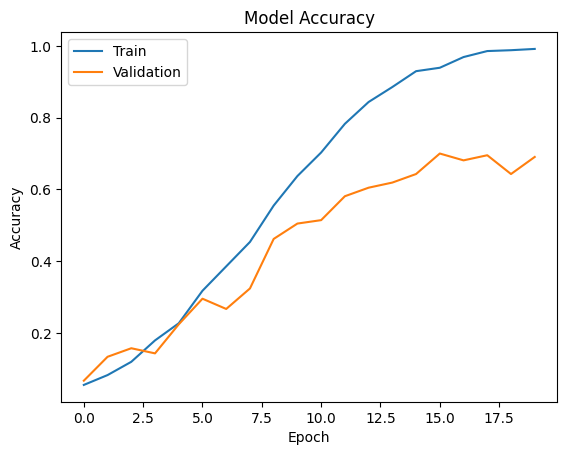

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

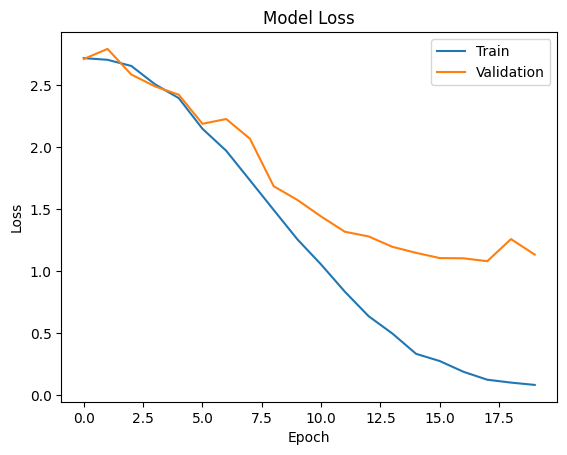

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


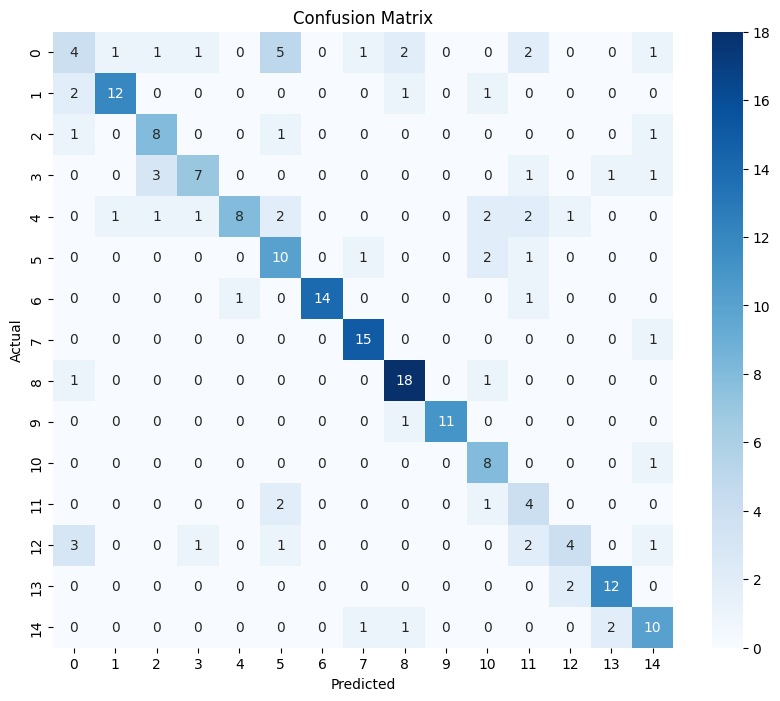

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
labels_map = {
0: "The person is walking with dog",
1: "The person is doing jumping jack",
2: "The person is doing push ups",
3: "The person is playing basketball",
4: "The person is juggling soccer ball",
5: "The person is playing volleyball",
6: "The person is playing tennis",
7: "The person is punching",
8: "The person is playing guitar",
9: "The person is playing piano",
10: "The person is playing golf",
11: "The person is riding a horse",
12: "The person is skateboarding",
13: "The person is surfing",
14: "The person is bowling"
}

In [ ]:
def test_video(video_path):

    frames = extract_frames(video_path)

    if len(frames) < 10:
        print("Video too short")
        return

    input_data = np.array(frames[:10])
    input_data = np.expand_dims(input_data, axis=0)

    pred = model.predict(input_data)
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    plt.imshow(frames[0])
    plt.title(labels_map[pred_class])
    plt.axis('off')
    plt.show()

    print("Prediction:", labels_map[pred_class])
    print("Confidence:", round(confidence*100,2), "%")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


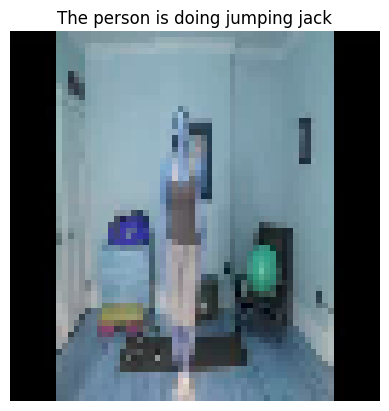

Prediction: The person is doing jumping jack
Confidence: 99.65 %


In [ ]:

test_video("/content/UCF-101/JumpingJack/v_JumpingJack_g01_c01.avi")

In [ ]:
predict_and_describe("/content/UCF-101/JumpingJack/v_JumpingJack_g01_c01.avi")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: The person is doing jumping jack
Confidence: 99.65 %


In [ ]:
import matplotlib.pyplot as plt

def full_test(idx=0):

    pred = model.predict(X_test[idx:idx+1])

    pred_class = np.argmax(pred)
    true_class = np.argmax(y_test[idx])

    frame = X_test[idx][0]

    plt.imshow(frame)
    plt.title(f"Pred: {labels_map[pred_class]} | True: {labels_map[true_class]}")
    plt.axis('off')
    plt.show()

    print("Predicted:", labels_map[pred_class])
    print("Actual:", labels_map[true_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


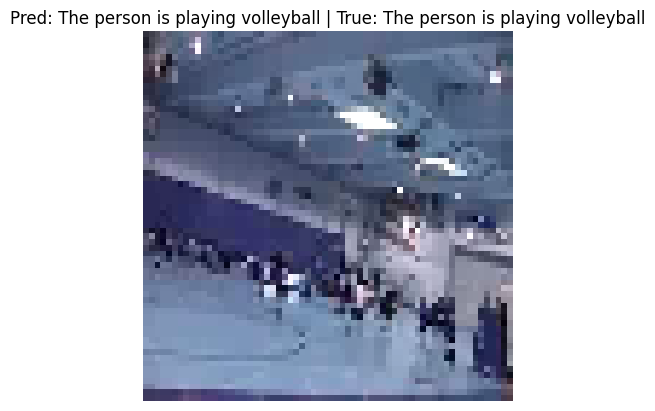

Predicted: The person is playing volleyball
Actual: The person is playing volleyball


In [ ]:
full_test(0)